Initializing sentiment analyzer...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Fetching messages for KO...

Analyzing 30 messages...


Analyzing sentiment: 100%|██████████| 30/30 [00:04<00:00,  7.49it/s]



Sample of analyzed messages:
                   datetime            user sentiment  \
0 2025-04-13 21:59:52+00:00      mikesterz7  negative   
1 2025-04-13 10:38:16+00:00  TradeInYourJob   neutral   
2 2025-04-12 21:31:57+00:00       Kascnef82   neutral   
3 2025-04-12 10:16:42+00:00         GemsBot   neutral   
4 2025-04-11 21:32:45+00:00  SilverTrader47  positive   

                                                body  
0  $KO \n\nCramer mentioned The Coca-Cola Company...  
1                   $KO Think we fill that gap soon?  
2                            $KO share a coke yuck 🤮  
3  6 of 11 $JPM $KO $MCD The best reward to risk ...  
4  @RunwithMoney15 @Scary09 I really like $DOW be...  

Sentiment Distribution:
sentiment
positive    16
negative    10
neutral      4
Name: count, dtype: int64


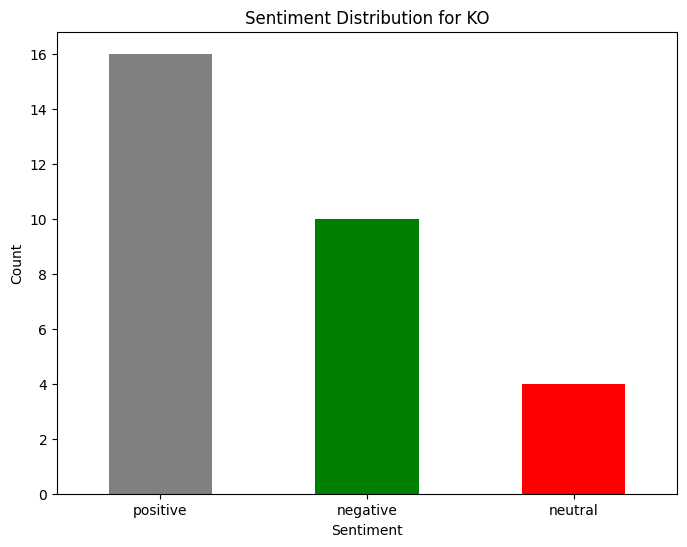

In [12]:
import torch
from transformers import BertForSequenceClassification, AutoTokenizer, pipeline
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# Initialize the sentiment classifier
def initialize_sentiment_analyzer():
    model = BertForSequenceClassification.from_pretrained(
        "StephanAkkerman/FinTwitBERT-sentiment",
        num_labels=3,
        id2label={0: "neutral", 1: "positive", 2: "negative"},
        label2id={"neutral": 0, "positive": 1, "negative": 2},
    )
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained("StephanAkkerman/FinTwitBERT-sentiment")

    sentiment_classifier = pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True  # This ensures consistent output format
    )
    return sentiment_classifier

# Initialize the analyzer
print("Initializing sentiment analyzer...")
sentiment_classifier = initialize_sentiment_analyzer()

# Function to fetch messages from StockTwits API
def fetch_stocktwits_messages(symbol, max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    messages = []

    try:
        print(f"Fetching messages for {symbol}...")
        response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()
        data = response.json()

        for msg in data.get('messages', [])[:max_messages]:
            messages.append({
                'id': msg['id'],
                'body': msg['body'],
                'created_at': msg['created_at'],
                'user': msg['user']['username']
            })

    except Exception as e:
        print(f"Error fetching messages: {e}")

    return messages

# Function to analyze sentiment of a single message
def analyze_single_message(text):
    try:
        results = sentiment_classifier(text)
        # The pipeline returns a list of dicts for each label when return_all_scores=True
        sentiment_scores = {result['label']: result['score'] for result in results[0]}
        predicted_sentiment = max(sentiment_scores.items(), key=lambda x: x[1])[0]
        return predicted_sentiment, sentiment_scores
    except Exception as e:
        print(f"Error analyzing message: {e}")
        return "error", {'neutral': 0, 'positive': 0, 'negative': 0}

# Function to analyze all messages
def analyze_messages(messages):
    results = []

    for msg in tqdm(messages, desc="Analyzing sentiment"):
        try:
            text = msg['body']
            sentiment, scores = analyze_single_message(text)

            msg['sentiment'] = sentiment
            msg.update(scores)
            results.append(msg)

        except Exception as e:
            print(f"Error processing message {msg['id']}: {e}")
            msg['sentiment'] = 'error'
            results.append(msg)

    return results

# Main analysis
def main():
    stock_symbol = "KO"  # Change to any stock symbol
    messages = fetch_stocktwits_messages(stock_symbol)

    if not messages:
        print("No messages fetched from StockTwits API")
        return

    print(f"\nAnalyzing {len(messages)} messages...")
    analyzed_messages = analyze_messages(messages)

    # Convert to DataFrame for analysis
    df = pd.DataFrame(analyzed_messages)

    # Convert created_at to datetime
    df['datetime'] = pd.to_datetime(df['created_at'])
    df['date'] = df['datetime'].dt.date

    # Show sample of results
    print("\nSample of analyzed messages:")
    print(df[['datetime', 'user', 'sentiment', 'body']].head())

    # Sentiment distribution
    sentiment_counts = df['sentiment'].value_counts()
    print("\nSentiment Distribution:")
    print(sentiment_counts)

    # Plot sentiment distribution
    plt.figure(figsize=(8, 6))
    sentiment_counts.plot(kind='bar', color=['gray', 'green', 'red'])
    plt.title(f'Sentiment Distribution for {stock_symbol}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

    # Save results
    #output_file = f'stocktwits_sentiment_{stock_symbol}.csv'
    #df.to_csv(output_file, index=False)
    #print(f"\nResults saved to {output_file}")

if __name__ == "__main__":
    main()

In [13]:
import pandas as pd
import torch
from transformers import BertForSequenceClassification, AutoTokenizer, pipeline

# Initialize FinTwitBERT sentiment analyzer
def initialize_sentiment_analyzer():
    model = BertForSequenceClassification.from_pretrained(
        "StephanAkkerman/FinTwitBERT-sentiment",
        num_labels=3,
        id2label={0: "neutral", 1: "positive", 2: "negative"},
        label2id={"neutral": 0, "positive": 1, "negative": 2},
    )
    tokenizer = AutoTokenizer.from_pretrained("StephanAkkerman/FinTwitBERT-sentiment")
    sentiment_classifier = pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True
    )
    return sentiment_classifier

sentiment_classifier = initialize_sentiment_analyzer()

# Fetch StockTwits messages (modify symbol as needed)
def fetch_stocktwits_messages(symbol="KO", max_messages=100):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
    data = response.json()
    return [msg['body'] for msg in data.get('messages', [])[:max_messages]]

messages = fetch_stocktwits_messages("KO")

# Analyze sentiment for each message
def analyze_messages(messages):
    sentiments = []
    for msg in messages:
        result = sentiment_classifier(msg)[0]  # Get first (and only) result
        sentiment_scores = {res['label']: res['score'] for res in result}
        sentiments.append(sentiment_scores)
    return pd.DataFrame(sentiments)

sentiment_df = analyze_messages(messages)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [14]:
# Simulate dates (replace with actual dates if available)
dates = pd.date_range(start="2023-01-01", periods=len(sentiment_df), freq="D")
sentiment_df['date'] = dates.date

# Aggregate daily sentiment
daily_sentiment = sentiment_df.groupby('date').agg({
    'neutral': 'mean',
    'positive': 'mean',
    'negative': 'mean'
}).reset_index()

# Add a "net sentiment" score (positive - negative)
daily_sentiment['net_sentiment'] = daily_sentiment['positive'] - daily_sentiment['negative']

In [15]:
import yfinance as yf

# Fetch stock data for the same period
stock_data = yf.download("KO", start="2023-01-01", end="2023-02-01")
stock_data.reset_index(inplace=True)
stock_data['date'] = stock_data['Date'].dt.date

[*********************100%***********************]  1 of 1 completed


In [16]:
stock_data.head()

Price,Date,Close,High,Low,Open,Volume,date
Ticker,,KO,KO,KO,KO,KO,
0,2023-01-03,58.782372,59.351987,58.063349,59.351987,12180500,2023-01-03
1,2023-01-04,58.754356,59.137216,58.371501,58.969132,13387900,2023-01-04
2,2023-01-05,58.082027,58.642303,57.969973,58.455543,9814700,2023-01-05
3,2023-01-06,59.202579,59.454701,58.436868,58.745019,9990000,2023-01-06
4,2023-01-09,58.464882,59.501394,58.436869,59.109199,9442600,2023-01-09


In [17]:
daily_sentiment.head()

,date,neutral,positive,negative,net_sentiment
0,2023-01-01,0.021205,0.364292,0.614502,-0.250210
1,2023-01-02,0.453487,0.263090,0.283423,-0.020333
2,2023-01-03,0.474250,0.358210,0.167540,0.190670
3,2023-01-04,0.733430,0.171896,0.094674,0.077222
4,2023-01-05,0.003497,0.989158,0.007345,0.981813


In [18]:
import pandas as pd

# 1. First, let's clean up the column names
def clean_column_name(col):
    return ''.join([c for c in col if c != '_'])

stock_data.columns = [clean_column_name(col) for col in stock_data.columns]

# 2. Now check the cleaned column names
print("Cleaned Columns:", stock_data.columns.tolist())

# 3. Convert dates in both DataFrames
stock_data['date'] = pd.to_datetime(stock_data['Date']).dt.date  # Use cleaned 'Date' column
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date']).dt.date

# 4. Merge the DataFrames
merged_data = pd.merge(
    stock_data,
    daily_sentiment,
    on='date',
    how='left'
).fillna(0)

merged_data.head()

Cleaned Columns: ['Date', 'CloseKO', 'HighKO', 'LowKO', 'OpenKO', 'VolumeKO', 'date']


,Date,CloseKO,HighKO,LowKO,OpenKO,VolumeKO,date,neutral,positive,negative,net_sentiment
0,2023-01-03,58.782372,59.351987,58.063349,59.351987,12180500,2023-01-03,0.474250,0.358210,0.167540,0.190670
1,2023-01-04,58.754356,59.137216,58.371501,58.969132,13387900,2023-01-04,0.733430,0.171896,0.094674,0.077222
2,2023-01-05,58.082027,58.642303,57.969973,58.455543,9814700,2023-01-05,0.003497,0.989158,0.007345,0.981813
3,2023-01-06,59.202579,59.454701,58.436868,58.745019,9990000,2023-01-06,0.087319,0.874400,0.038281,0.836119
4,2023-01-09,58.464882,59.501394,58.436869,59.109199,9442600,2023-01-09,0.057614,0.876885,0.065501,0.811383


In [19]:
# Calculate daily price change (%)
merged_data['price_change'] = merged_data['CloseKO'].pct_change() * 100

# Shift sentiment forward (today's sentiment predicts tomorrow's price)
merged_data['target_change'] = merged_data['price_change'].shift(-1)

# Drop rows with NaN (last row has no target)
merged_data.dropna(inplace=True)

merged_data.head()

,Date,CloseKO,HighKO,LowKO,OpenKO,VolumeKO,date,neutral,positive,negative,net_sentiment,price_change,target_change
1,2023-01-04,58.754356,59.137216,58.371501,58.969132,13387900,2023-01-04,0.733430,0.171896,0.094674,0.077222,-0.047659,-1.144305
2,2023-01-05,58.082027,58.642303,57.969973,58.455543,9814700,2023-01-05,0.003497,0.989158,0.007345,0.981813,-1.144305,1.929258
3,2023-01-06,59.202579,59.454701,58.436868,58.745019,9990000,2023-01-06,0.087319,0.874400,0.038281,0.836119,1.929258,-1.246057
4,2023-01-09,58.464882,59.501394,58.436869,59.109199,9442600,2023-01-09,0.057614,0.876885,0.065501,0.811383,-1.246057,-0.766647
5,2023-01-10,58.016663,58.576938,57.820563,58.455544,10134600,2023-01-10,0.311067,0.455948,0.232985,0.222964,-0.766647,-0.193159


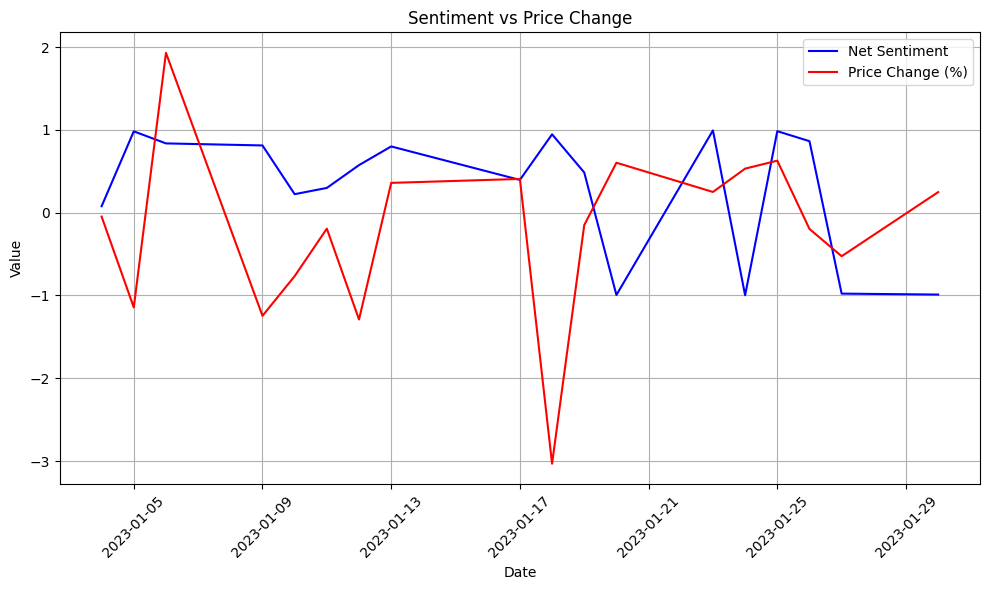

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(merged_data['Date'], merged_data['net_sentiment'], 'b-', label='Net Sentiment')
plt.plot(merged_data['Date'], merged_data['price_change'], 'r-', label='Price Change (%)')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Sentiment vs Price Change')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Features: Sentiment scores + past price changes
features = ['neutral', 'positive', 'negative', 'net_sentiment', 'price_change']
X = merged_data[features]
y = merged_data['target_change']

# Split data (time-series, so no shuffling!)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f}%")

Mean Absolute Error: 0.49%


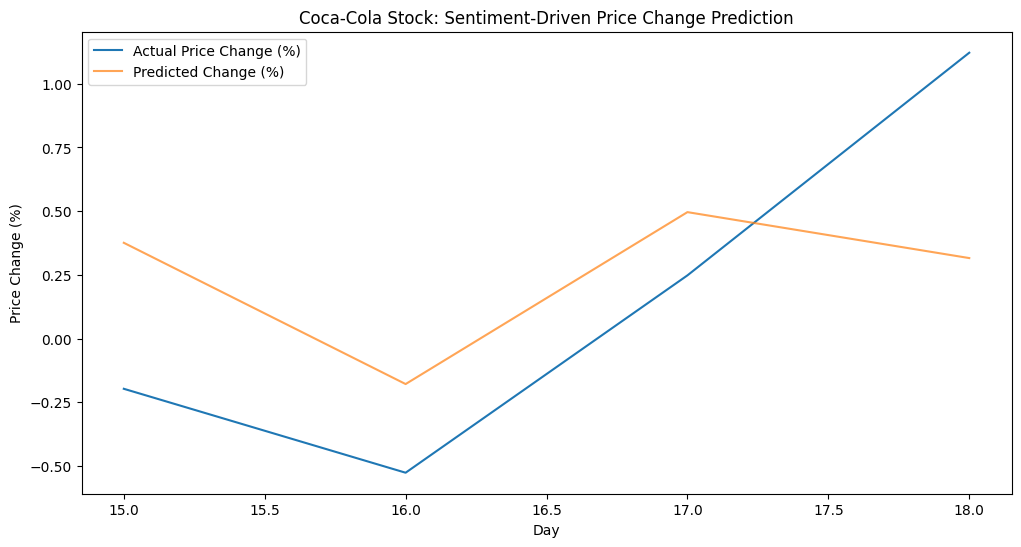

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Price Change (%)')
plt.plot(y_test.index, predictions, label='Predicted Change (%)', alpha=0.7)
plt.title("Coca-Cola Stock: Sentiment-Driven Price Change Prediction")
plt.xlabel("Day")
plt.ylabel("Price Change (%)")
plt.legend()
plt.show()